<a href="https://colab.research.google.com/github/jayvee2010/edp-project/blob/main/edp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing required libraries
import pandas as pd          # For data loading and manipulation
import numpy as np           # For numerical statistics
import matplotlib.pyplot as plt   # For plotting charts
import seaborn as sns        # For advanced visualizations

# Display settings
pd.set_option('display.max_columns', None)   # Show all columns
plt.rcParams['figure.figsize'] = (12, 6)     # Default chart size
sns.set_theme(style="whitegrid")             # Clean chart background

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Most Streamed Spotify Songs 2024.csv to Most Streamed Spotify Songs 2024.csv


In [ ]:
# Loading the dataset
df = pd.read_csv('Most Streamed Spotify Songs 2024.csv', encoding='latin-1')
# Note: encoding='latin-1' handles special characters in song/artist names

# Preview first 5 rows
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (4600, 29)

First 5 rows:


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210.0,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188.0,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190.0,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85.0,"1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582",394.0,"1,474,799","2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88.0,"77,373,957","3,670,188","16,400",NaN,NaN,"112,763,851",182.0,"12,185",1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [ ]:
# Understanding the dataset features
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC DATASET INFO ===")
df.info()

=== COLUMN NAMES ===
['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']

=== DATA TYPES ===
Track                          object
Album Name                     object
Artist                         object
Release Date                   object
ISRC                           object
All Time Rank                  object
Track Score                   float64
Spotify Streams                object
Spotify Playlist Count         object
Spotify Playlist Reach         object
Spotify Popularity        

In [ ]:
print(df.columns.tolist())

['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']


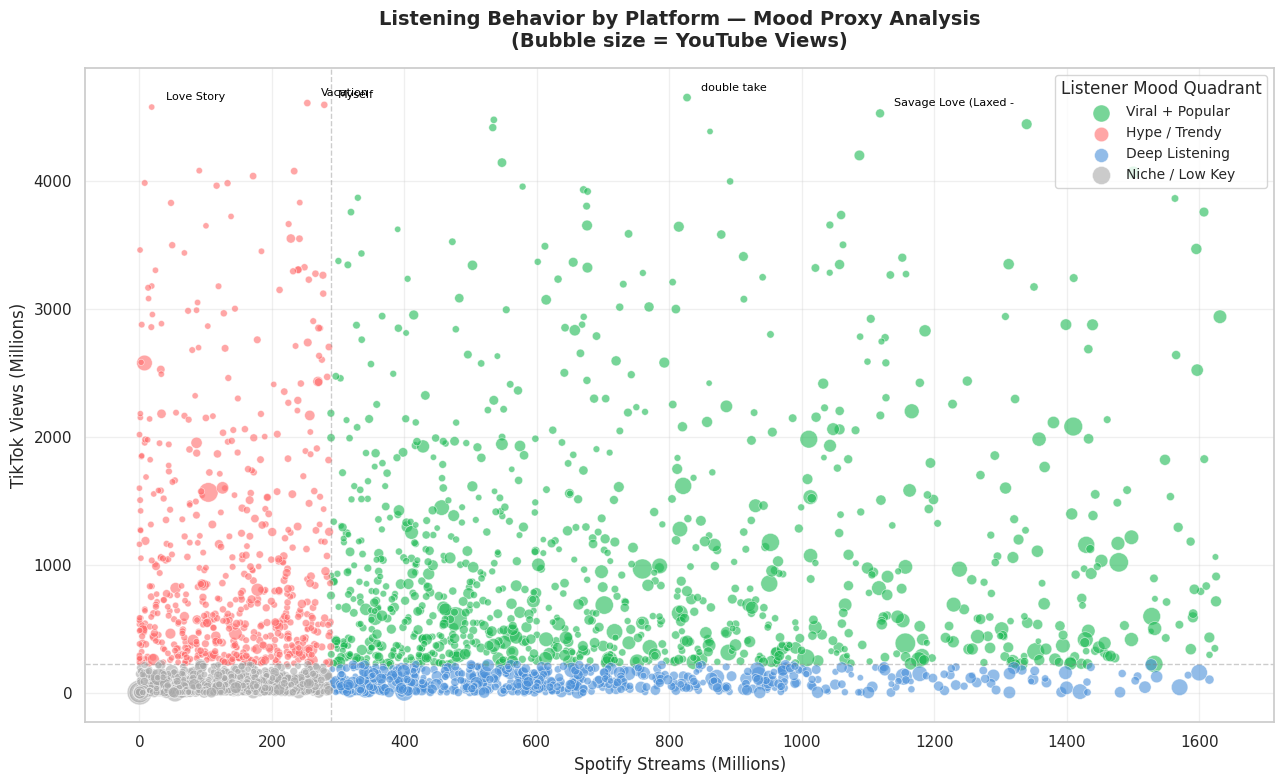

Graph 1 saved as mood_proxy_graph.png


In [ ]:
# ================================================
# GRAPH 1: Platform Listening Behavior (Mood Proxy)
# TikTok Views vs Spotify Streams
# Insight: TikTok = trend-driven/hype mood
#          Spotify = dedicated/deep listening mood
# ================================================

import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Clean the data ---
# These columns sometimes have commas or non-numeric characters, so we force them to numbers
cols_to_clean = ['Spotify Streams', 'TikTok Views', 'YouTube Views', 'TikTok Likes']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# Drop rows where either axis column is missing
graph1_df = df[['Track', 'Artist', 'Spotify Streams', 'TikTok Views', 'YouTube Views']].dropna()

# --- Step 2: Remove extreme outliers for cleaner plot (keep top 95%) ---
sp_cap = graph1_df['Spotify Streams'].quantile(0.95)
tk_cap = graph1_df['TikTok Views'].quantile(0.95)
graph1_df = graph1_df[
    (graph1_df['Spotify Streams'] <= sp_cap) &
    (graph1_df['TikTok Views'] <= tk_cap)
]

# --- Step 3: Normalize YouTube Views for bubble size ---
bubble_size = (graph1_df['YouTube Views'] / graph1_df['YouTube Views'].max()) * 300 + 20

# --- Step 4: Color-code by dominant platform (mood quadrant) ---
# High TikTok + Low Spotify = Hype/Trendy mood
# Low TikTok + High Spotify = Calm/Dedicated mood
sp_median = graph1_df['Spotify Streams'].median()
tk_median = graph1_df['TikTok Views'].median()

def assign_mood(row):
    if row['TikTok Views'] >= tk_median and row['Spotify Streams'] >= sp_median:
        return ('Viral + Popular', '#1DB954')      # Green
    elif row['TikTok Views'] >= tk_median and row['Spotify Streams'] < sp_median:
        return ('Hype / Trendy', '#FF6B6B')        # Red
    elif row['TikTok Views'] < tk_median and row['Spotify Streams'] >= sp_median:
        return ('Deep Listening', '#4A90D9')        # Blue
    else:
        return ('Niche / Low Key', '#A9A9A9')       # Gray

mood_data = graph1_df.apply(assign_mood, axis=1)
graph1_df = graph1_df.copy()
graph1_df['Mood Label'] = [m[0] for m in mood_data]
graph1_df['Mood Color'] = [m[1] for m in mood_data]

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(13, 8))

for mood, color in [('Viral + Popular', '#1DB954'),
                     ('Hype / Trendy',   '#FF6B6B'),
                     ('Deep Listening',  '#4A90D9'),
                     ('Niche / Low Key', '#A9A9A9')]:
    mask = graph1_df['Mood Label'] == mood
    ax.scatter(
        graph1_df[mask]['Spotify Streams'] / 1e6,
        graph1_df[mask]['TikTok Views'] / 1e6,
        s=bubble_size[mask],
        c=color,
        alpha=0.6,
        label=mood,
        edgecolors='white',
        linewidths=0.5
    )

# --- Step 6: Annotate top 5 most viral songs ---
top5 = graph1_df.nlargest(5, 'TikTok Views')
for _, row in top5.iterrows():
    ax.annotate(
        row['Track'][:20],  # Trim long names
        xy=(row['Spotify Streams']/1e6, row['TikTok Views']/1e6),
        xytext=(10, 5), textcoords='offset points',
        fontsize=8, color='black'
    )

# --- Step 7: Labels and formatting ---
ax.set_xlabel('Spotify Streams (Millions)', fontsize=12)
ax.set_ylabel('TikTok Views (Millions)', fontsize=12)
ax.set_title('Listening Behavior by Platform — Mood Proxy Analysis\n(Bubble size = YouTube Views)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Listener Mood Quadrant', fontsize=10)
ax.grid(True, alpha=0.3)

# Median lines as quadrant dividers
ax.axvline(x=sp_median/1e6, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=tk_median/1e6, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('mood_proxy_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph 1 saved as mood_proxy_graph.png")

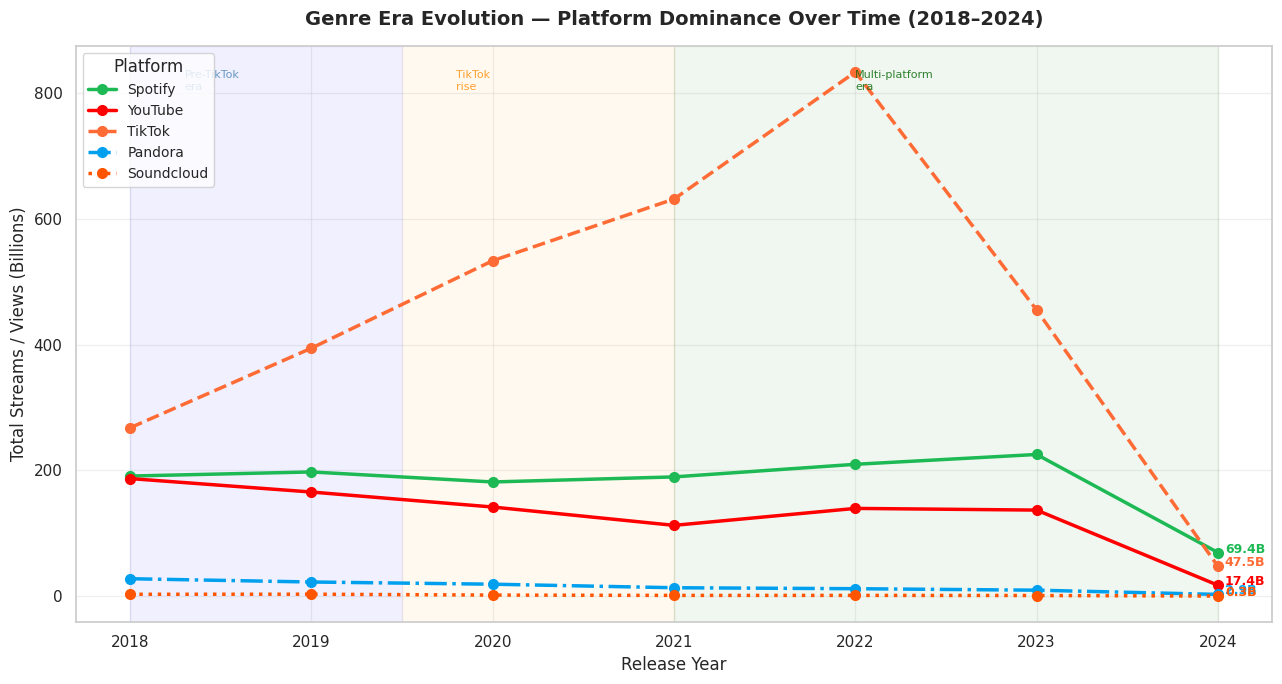

Graph 2 saved as genre_evolution_timeline.png


In [ ]:
# ================================================
# GRAPH 2: Genre / Era Evolution Timeline
# Shows how different platform eras dominated
# over release years (2018–2024)
# ================================================

# --- Step 1: Parse Release Date and extract Year ---
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year

# Keep only years with enough data (2018–2024)
timeline_df = df[df['Release Year'].between(2018, 2024)].copy()

# --- Step 2: Clean platform stream columns ---
platform_cols = ['Spotify Streams', 'YouTube Views', 'TikTok Views',
                 'Pandora Streams', 'Soundcloud Streams']
for col in platform_cols:
    timeline_df[col] = pd.to_numeric(
        timeline_df[col].astype(str).str.replace(',', ''), errors='coerce'
    )

# --- Step 3: Group by year — total streams per platform ---
yearly = timeline_df.groupby('Release Year')[platform_cols].sum() / 1e9  # Convert to Billions

# --- Step 4: Plot multi-line timeline ---
fig, ax = plt.subplots(figsize=(13, 7))

colors    = ['#1DB954', '#FF0000', '#FF6B35', '#00A0EE', '#FF5500']
linestyles = ['-',      '-',       '--',       '-.',      ':']
labels    = ['Spotify', 'YouTube', 'TikTok', 'Pandora', 'Soundcloud']

for col, color, ls, label in zip(platform_cols, colors, linestyles, labels):
    ax.plot(
        yearly.index,
        yearly[col],
        marker='o',
        color=color,
        linestyle=ls,
        linewidth=2.5,
        markersize=7,
        label=label
    )
    # Annotate last point with value
    last_year = yearly.index[-1]
    ax.annotate(
        f"{yearly[col].iloc[-1]:.1f}B",
        xy=(last_year, yearly[col].iloc[-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold'
    )

# --- Step 5: Add era annotations ---
ax.axvspan(2018, 2019.5, alpha=0.06, color='blue',   label='_Pre-TikTok era')
ax.axvspan(2019.5, 2021, alpha=0.06, color='orange', label='_TikTok rise')
ax.axvspan(2021, 2024,  alpha=0.06, color='green',  label='_Multi-platform era')

ax.text(2018.3, ax.get_ylim()[1]*0.92, 'Pre-TikTok\nera',    fontsize=8, color='steelblue', alpha=0.8)
ax.text(2019.8, ax.get_ylim()[1]*0.92, 'TikTok\nrise',       fontsize=8, color='darkorange', alpha=0.8)
ax.text(2022.0, ax.get_ylim()[1]*0.92, 'Multi-platform\nera', fontsize=8, color='darkgreen', alpha=0.8)

# --- Step 6: Formatting ---
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Total Streams / Views (Billions)', fontsize=12)
ax.set_title('Genre Era Evolution — Platform Dominance Over Time (2018–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(yearly.index)
ax.legend(title='Platform', fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('genre_evolution_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 saved as genre_evolution_timeline.png")

In [ ]:
# Run this and paste the output here
print(df['Artist'].head(20).tolist())

['Tommy Richman', 'Kendrick Lamar', 'Artemas', 'Miley Cyrus', 'Eminem', 'Jack Harlow', 'Benson Boone', 'FloyyMenor', 'MUSIC LAB JPN', 'Central Cee', 'Post Malone', 'Teddy Swims', 'Billie Eilish', 'Future', 'Kids With Buns', 'Myke Towers', 'Taylor Swift', 'Tate McRae', 'Billie Eilish', 'Harry Styles']


In [ ]:
# Cell 1: Search for collaboration keywords in Track names
collab_tracks = df[df['Track'].str.contains('ft|feat|with|&', case=False, na=False)]
print(f"Collabs found in Track column: {len(collab_tracks)}")
print(collab_tracks[['Track', 'Artist']].head(10))

Collabs found in Track column: 671
                                                Track         Artist
9                          BAND4BAND (feat. Lil Baby)    Central Cee
10              I Had Some Help (feat. Morgan Wallen)    Post Malone
16                      Fortnight (feat. Post Malone)   Taylor Swift
26                          STAY (with Justin Bieber)  The Kid LAROI
35      What's Love Got to Do with It - 2023 Remaster    Tina Turner
40                                 BIRDS OF A FEATHER  Billie Eilish
41  Cupid ï¿½ï¿½ï¿½ Twin Ver. (FIFTY FIFTY) ï¿½ï¿½...   sped up 8282
52                      Calm Down (with Selena Gomez)           Rema
56             Creepin' (with The Weeknd & 21 Savage)   Metro Boomin
59                          Unholy (feat. Kim Petras)      Sam Smith


In [ ]:
# Cell 2: Search for collaboration keywords in Artist column
collab_artists = df[df['Artist'].str.contains(',|ft|feat|&| x ', case=False, na=False)]
print(f"Collabs found in Artist column: {len(collab_artists)}")
print(collab_artists[['Track', 'Artist']].head(10))

Collabs found in Artist column: 118
                                                 Track         Artist
16                       Fortnight (feat. Post Malone)   Taylor Swift
90                                           Anti-Hero   Taylor Swift
227                                  Cupid - Twin Ver.    FIFTY FIFTY
239  Is It Over Now? (Taylor's Version) (From The V...   Taylor Swift
266                    I Can Do It With a Broken Heart   Taylor Swift
452                                       Cruel Summer   Taylor Swift
460                            ýýýýýýýýýý ýýýýýýýýýýýý       ALEX&RUS
464                                        Blank Space   Taylor Swift
507                                           Down Bad   Taylor Swift
537               Work from Home (feat. Ty Dolla $ign)  Fifth Harmony


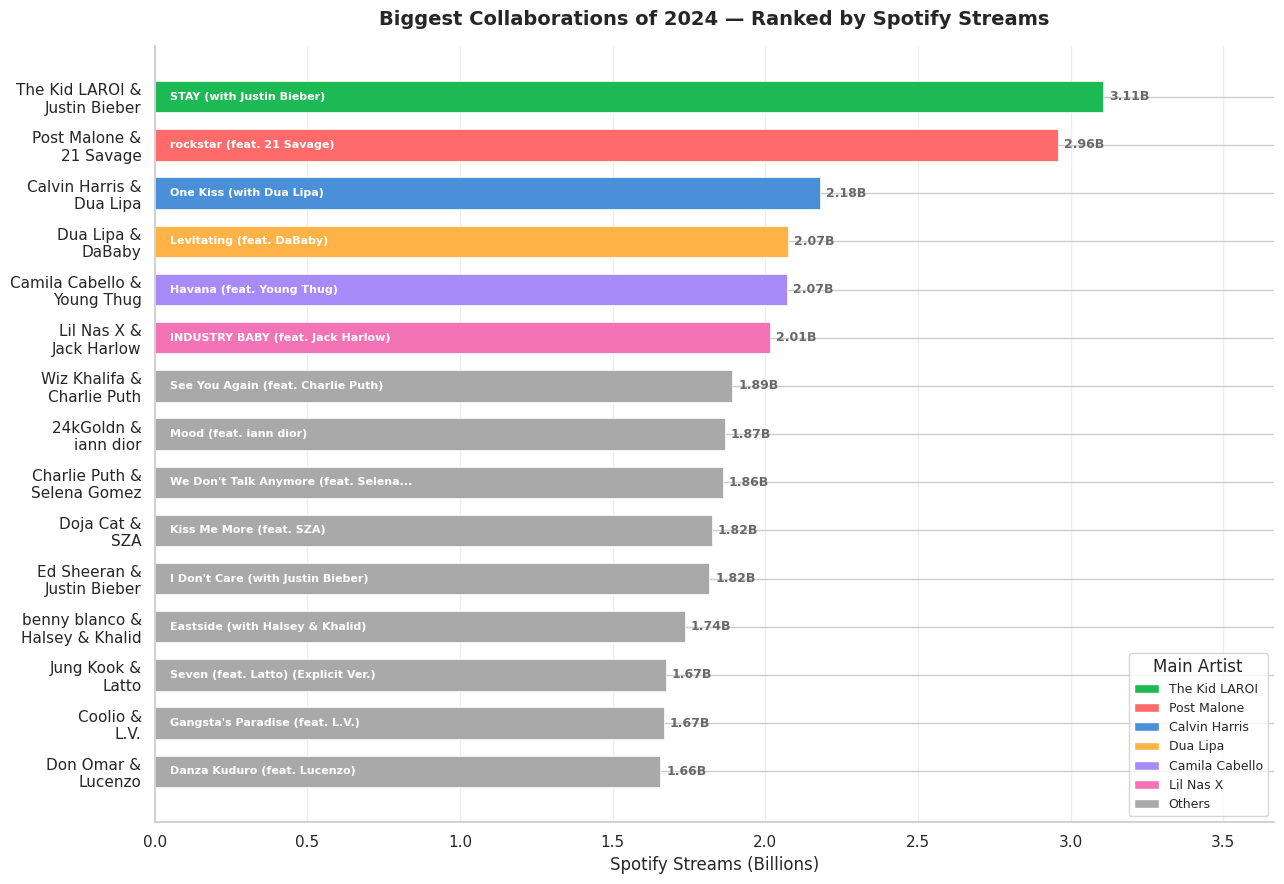

Graph saved! Total collaborations analysed: 525


In [ ]:
# ================================================
# GRAPH: Biggest Collaborations of 2024
# Extracts featured artists from Track names
# Ranks collabs by Spotify Streams
# ================================================

import re

# --- Step 1: Clean Spotify Streams column ---
df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

# --- Step 2: Extract featured artist from Track name ---
# Handles: (feat. X), (with X), (ft. X) — case insensitive
def extract_featured(track):
    match = re.search(
        r'\((?:feat|ft|with)\.?\s+([^)]+)\)',
        str(track), re.IGNORECASE
    )
    if match:
        return match.group(1).strip()
    return None

df['Featured Artist'] = df['Track'].apply(extract_featured)

# --- Step 3: Keep only collab rows with stream data ---
collabs = df[df['Featured Artist'].notna()].copy()
collabs = collabs.dropna(subset=['Spotify Streams'])

# --- Step 4: Build collab pair label ---
# Format: "Main Artist & Featured Artist"
collabs['Collab Pair'] = collabs['Artist'] + ' &\n' + collabs['Featured Artist']

# --- Step 5: Get top 15 collabs by Spotify Streams ---
top_collabs = (
    collabs[['Collab Pair', 'Track', 'Spotify Streams', 'Artist']]
    .sort_values('Spotify Streams', ascending=False)
    .drop_duplicates(subset='Collab Pair')
    .head(15)
    .reset_index(drop=True)
)

# --- Step 6: Assign colors by main artist (top artists get unique colors) ---
top_artists = top_collabs['Artist'].value_counts().head(6).index.tolist()
color_map = {
    artist: color for artist, color in zip(
        top_artists,
        ['#1DB954','#FF6B6B','#4A90D9','#FFB347','#A78BFA','#F472B6']
    )
}
bar_colors = [color_map.get(a, '#A9A9A9') for a in top_collabs['Artist']]

# --- Step 7: Plot horizontal bar chart ---
fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    top_collabs['Collab Pair'],
    top_collabs['Spotify Streams'] / 1e9,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

# --- Step 8: Add stream value labels at end of each bar ---
for bar, (_, row) in zip(bars, top_collabs.iterrows()):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Spotify Streams']/1e9:.2f}B",
        va='center', fontsize=9, color='dimgray', fontweight='bold'
    )

# --- Step 9: Add track name inside each bar ---
for bar, (_, row) in zip(bars, top_collabs.iterrows()):
    track_label = row['Track'][:35] + '...' if len(row['Track']) > 35 else row['Track']
    ax.text(
        0.05,
        bar.get_y() + bar.get_height() / 2,
        track_label,
        va='center', fontsize=8,
        color='white', fontweight='bold'
    )

# --- Step 10: Legend for main artists ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map[a], label=a)
    for a in top_artists if a in color_map
]
legend_elements.append(Patch(facecolor='#A9A9A9', label='Others'))
ax.legend(
    handles=legend_elements,
    title='Main Artist',
    loc='lower right',
    fontsize=9
)

# --- Step 11: Formatting ---
ax.invert_yaxis()   # Highest streams at top
ax.set_xlabel('Spotify Streams (Billions)', fontsize=12)
ax.set_title(
    'Biggest Collaborations of 2024 — Ranked by Spotify Streams',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, top_collabs['Spotify Streams'].max() / 1e9 * 1.18)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('biggest_collabs_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Graph saved! Total collaborations analysed: {len(collabs)}")

In [ ]:
print(df['Album Name'].nunique())
print(df['Album Name'].value_counts().head(10))

4005
Album Name
Un Verano Sin Ti                        20
THE TORTURED POETS DEPARTMENT           18
nadie sabe lo que va a pasar maï¿½ï¿    16
UTOPIA                                  15
For All The Dogs                        15
Full Circle: The Live Anthology         13
Papercuts                               11
WE DON'T TRUST YOU                      11
Her Loss                                11
HIT ME HARD AND SOFT                    10
Name: count, dtype: int64


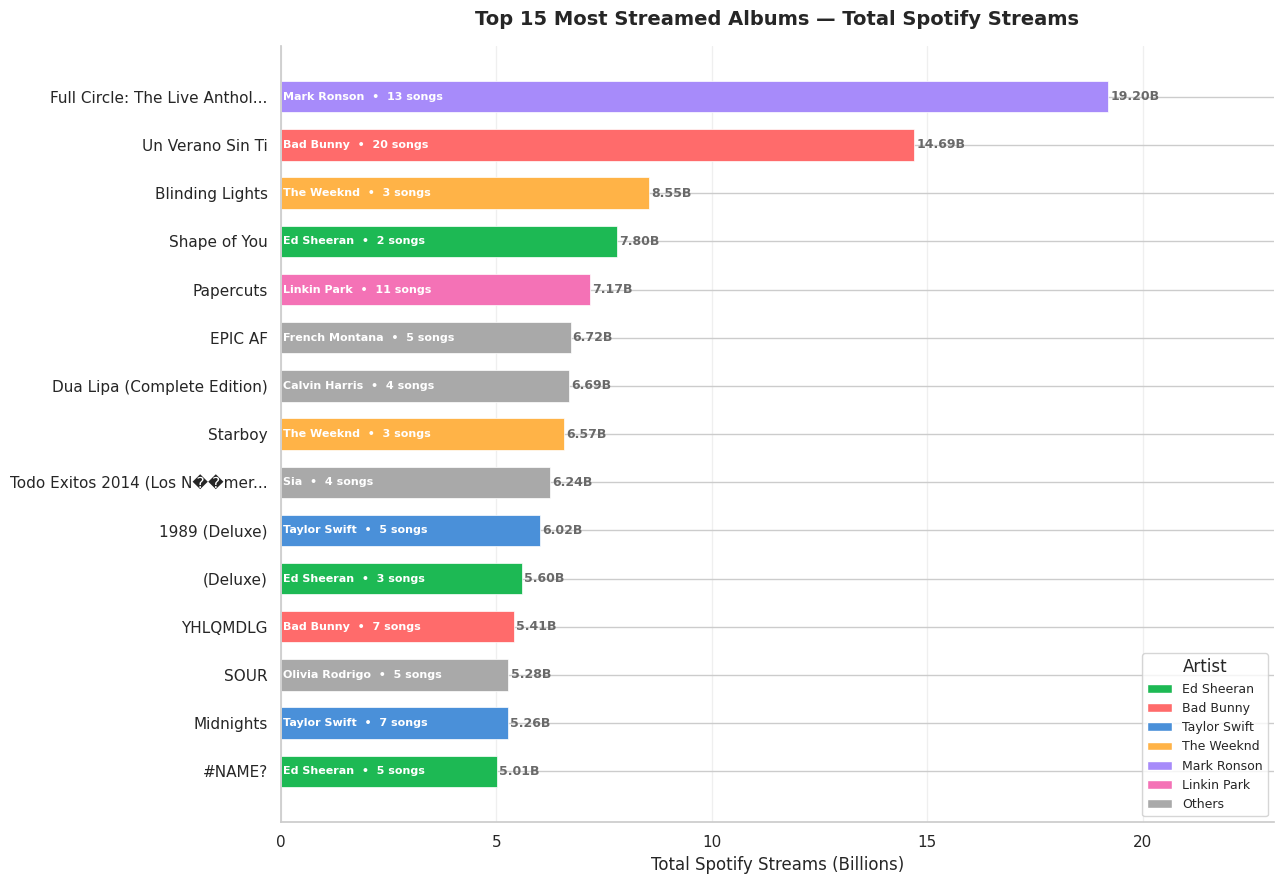

Graph saved! Analysed 3995 unique albums.


In [ ]:
# ================================================
# GRAPH: Top 15 Albums by Total Spotify Streams
# Bar chart with song count labels and artist info
# ================================================

# --- Step 1: Clean Spotify Streams ---
df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

# --- Step 2: Fix encoding issues in Album Name ---
df['Album Name Clean'] = (
    df['Album Name']
    .astype(str)
    .str.encode('latin-1', errors='ignore')
    .str.decode('utf-8', errors='ignore')
    .str.strip()
)
# Fallback: if clean version is empty, use original
df['Album Name Clean'] = df.apply(
    lambda r: r['Album Name'] if len(str(r['Album Name Clean'])) < 2
    else r['Album Name Clean'], axis=1
)

# --- Step 3 FIX: Group by album safely ---
def safe_top_artist(x):
    counts = x.value_counts()
    if len(counts) == 0:
        return 'Unknown'
    return counts.index[0]

album_streams = df.groupby('Album Name Clean').agg(
    Total_Streams = ('Spotify Streams', 'sum'),
    Song_Count    = ('Track', 'count'),
    Main_Artist   = ('Artist', safe_top_artist)
).reset_index()

# --- Step 4: Top 15 albums by total streams ---
top_albums = (
    album_streams
    .sort_values('Total_Streams', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# --- Step 5: Assign colors by artist ---
top_artists = top_albums['Main_Artist'].value_counts().head(6).index.tolist()
palette = ['#1DB954','#FF6B6B','#4A90D9','#FFB347','#A78BFA','#F472B6']
color_map = dict(zip(top_artists, palette))
bar_colors = [color_map.get(a, '#A9A9A9') for a in top_albums['Main_Artist']]

# --- Step 6: Shorten long album names for display ---
top_albums['Album Label'] = top_albums['Album Name Clean'].apply(
    lambda x: x[:28] + '...' if len(x) > 28 else x
)

# --- Step 7: Plot ---
fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    top_albums['Album Label'],
    top_albums['Total_Streams'] / 1e9,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

# --- Step 8: Add total stream value at end of bar ---
for bar, (_, row) in zip(bars, top_albums.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Total_Streams']/1e9:.2f}B",
        va='center', fontsize=9,
        color='dimgray', fontweight='bold'
    )

# --- Step 9: Add artist name + song count inside bar ---
for bar, (_, row) in zip(bars, top_albums.iterrows()):
    label = f"{row['Main_Artist']}  •  {row['Song_Count']} songs"
    ax.text(
        0.05,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=8,
        color='white', fontweight='bold'
    )

# --- Step 10: Legend for artists ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map[a], label=a) for a in top_artists
]
legend_elements.append(Patch(facecolor='#A9A9A9', label='Others'))
ax.legend(
    handles=legend_elements,
    title='Artist',
    loc='lower right',
    fontsize=9
)

# --- Step 11: Formatting ---
ax.invert_yaxis()
ax.set_xlabel('Total Spotify Streams (Billions)', fontsize=12)
ax.set_title(
    'Top 15 Most Streamed Albums — Total Spotify Streams',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, top_albums['Total_Streams'].max() / 1e9 * 1.2)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('top_albums.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Graph saved! Analysed {len(album_streams)} unique albums.")

In [ ]:
print(df.columns.tolist())

['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track', 'Release Year', 'Featured Artist', 'Album Name Clean']


In [ ]:
# ================================================
# GRAPH: Language Distribution of Top Streamed Songs
# Uses langdetect library to detect language
# from Track names, then plots as pie + bar chart
# ================================================

# --- Step 1: Install langdetect (only needed once in Colab) ---
!pip install langdetect -q

from langdetect import detect, LangDetectException

# --- Step 2: Detect language from Track name ---
def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

print("Detecting languages... this may take 30-60 seconds...")
df['Language Code'] = df['Track'].apply(detect_language)
print("Done!")
print(df['Language Code'].value_counts().head(10))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Detecting languages... this may take 30-60 seconds...
Done!
Language Code
en    1838
de     422
es     202
ca     197
id     179
it     164
pt     161
tl     158
so     124
fr     110
Name: count, dtype: int64


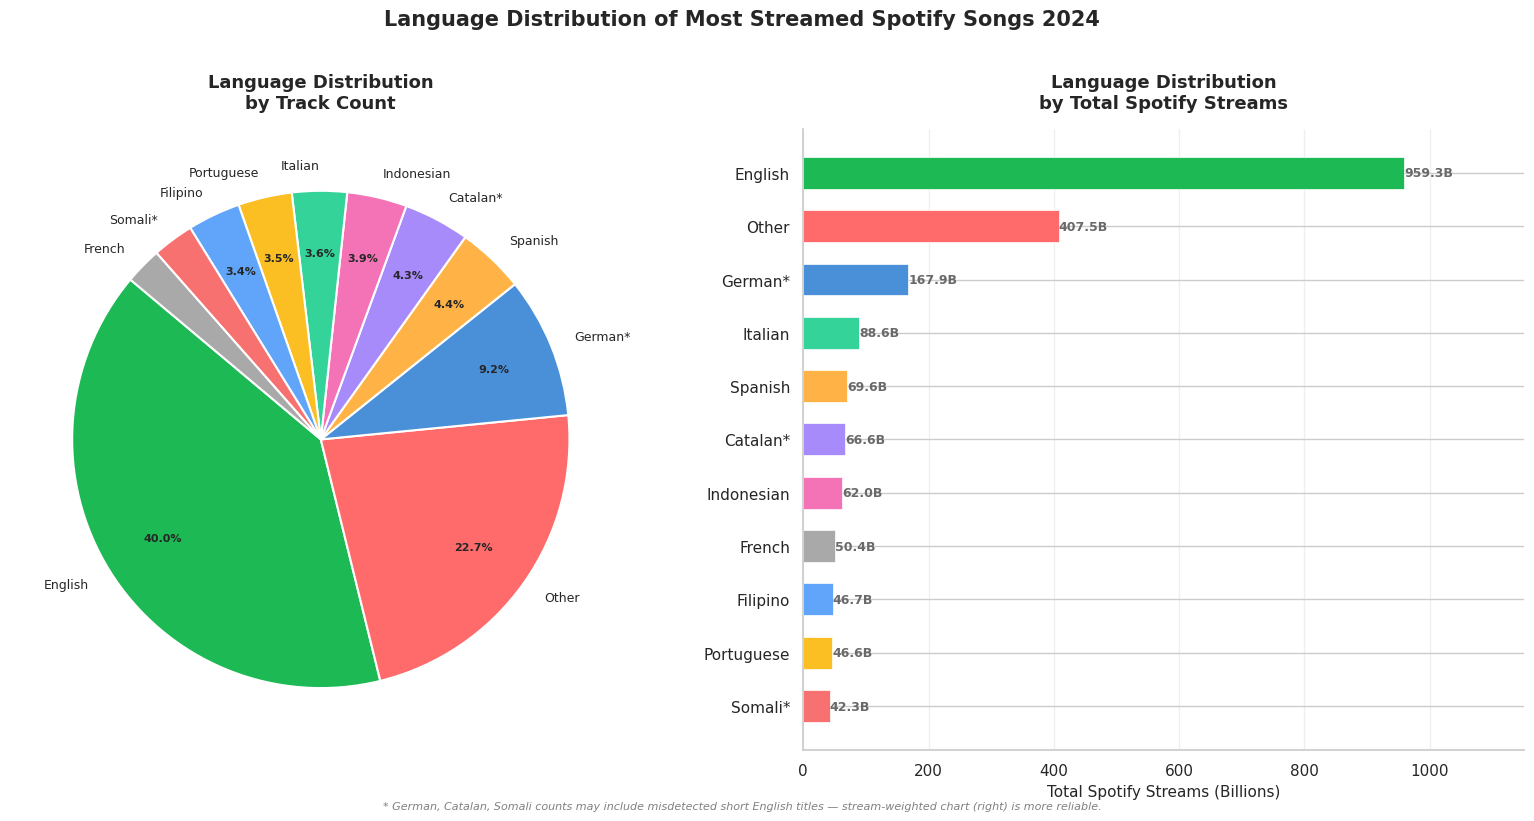

Graph saved as language_distribution.png


In [ ]:
# ================================================
# GRAPH: Language Distribution of Top Streamed Songs
# Side-by-side: Pie (by track count) + Bar (by streams)
# ================================================

# --- Step 1: Map language codes to full names ---
language_map = {
    'en': 'English',
    'es': 'Spanish',
    'de': 'German*',      # * = may include misdetected English
    'ca': 'Catalan*',
    'id': 'Indonesian',
    'it': 'Italian',
    'pt': 'Portuguese',
    'tl': 'Filipino',
    'so': 'Somali*',
    'fr': 'French',
    'ko': 'Korean',
    'ja': 'Japanese',
    'zh-cn': 'Chinese',
    'ar': 'Arabic',
    'unknown': 'Unknown'
}

df['Language'] = df['Language Code'].map(language_map).fillna('Other')

# --- Step 2: Clean Spotify Streams ---
df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

# --- Step 3: Count by language (track count) ---
lang_counts = df['Language'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Track Count']

# Group languages with < 100 tracks into 'Other'
lang_counts['Language'] = lang_counts.apply(
    lambda r: r['Language'] if r['Track Count'] >= 100 else 'Other', axis=1
)
lang_counts = lang_counts.groupby('Language')['Track Count'].sum().reset_index()
lang_counts = lang_counts.sort_values('Track Count', ascending=False)

# --- Step 4: Total streams by language ---
lang_streams = df.groupby('Language')['Spotify Streams'].sum().reset_index()
lang_streams.columns = ['Language', 'Total Streams']
lang_streams['Language'] = lang_streams.apply(
    lambda r: r['Language'] if r['Language'] in lang_counts['Language'].values else 'Other',
    axis=1
)
lang_streams = lang_streams.groupby('Language')['Total Streams'].sum().reset_index()
lang_streams = lang_streams.sort_values('Total Streams', ascending=False)

# --- Step 5: Color palette ---
colors = [
    '#1DB954','#FF6B6B','#4A90D9','#FFB347',
    '#A78BFA','#F472B6','#34D399','#FBBF24',
    '#60A5FA','#F87171','#A9A9A9'
]
lang_colors = {
    lang: colors[i % len(colors)]
    for i, lang in enumerate(lang_counts['Language'])
}

# --- Step 6: Plot side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- LEFT: Pie chart by track count ---
pie_colors = [lang_colors.get(l, '#A9A9A9') for l in lang_counts['Language']]

wedges, texts, autotexts = ax1.pie(
    lang_counts['Track Count'],
    labels=lang_counts['Language'],
    colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

ax1.set_title(
    'Language Distribution\nby Track Count',
    fontsize=13, fontweight='bold', pad=15
)

# --- RIGHT: Horizontal bar chart by total streams ---
bar_colors = [lang_colors.get(l, '#A9A9A9') for l in lang_streams['Language']]

bars = ax2.barh(
    lang_streams['Language'],
    lang_streams['Total Streams'] / 1e9,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Value labels
for bar in bars:
    ax2.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}B',
        va='center', fontsize=9,
        color='dimgray', fontweight='bold'
    )

ax2.invert_yaxis()
ax2.set_xlabel('Total Spotify Streams (Billions)', fontsize=11)
ax2.set_title(
    'Language Distribution\nby Total Spotify Streams',
    fontsize=13, fontweight='bold', pad=15
)
ax2.set_xlim(0, lang_streams['Total Streams'].max() / 1e9 * 1.2)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Note about misdetections ---
fig.text(
    0.5, 0.01,
    '* German, Catalan, Somali counts may include misdetected short English titles — '
    'stream-weighted chart (right) is more reliable.',
    ha='center', fontsize=8, color='gray', style='italic'
)

plt.suptitle(
    'Language Distribution of Most Streamed Spotify Songs 2024',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved as language_distribution.png")

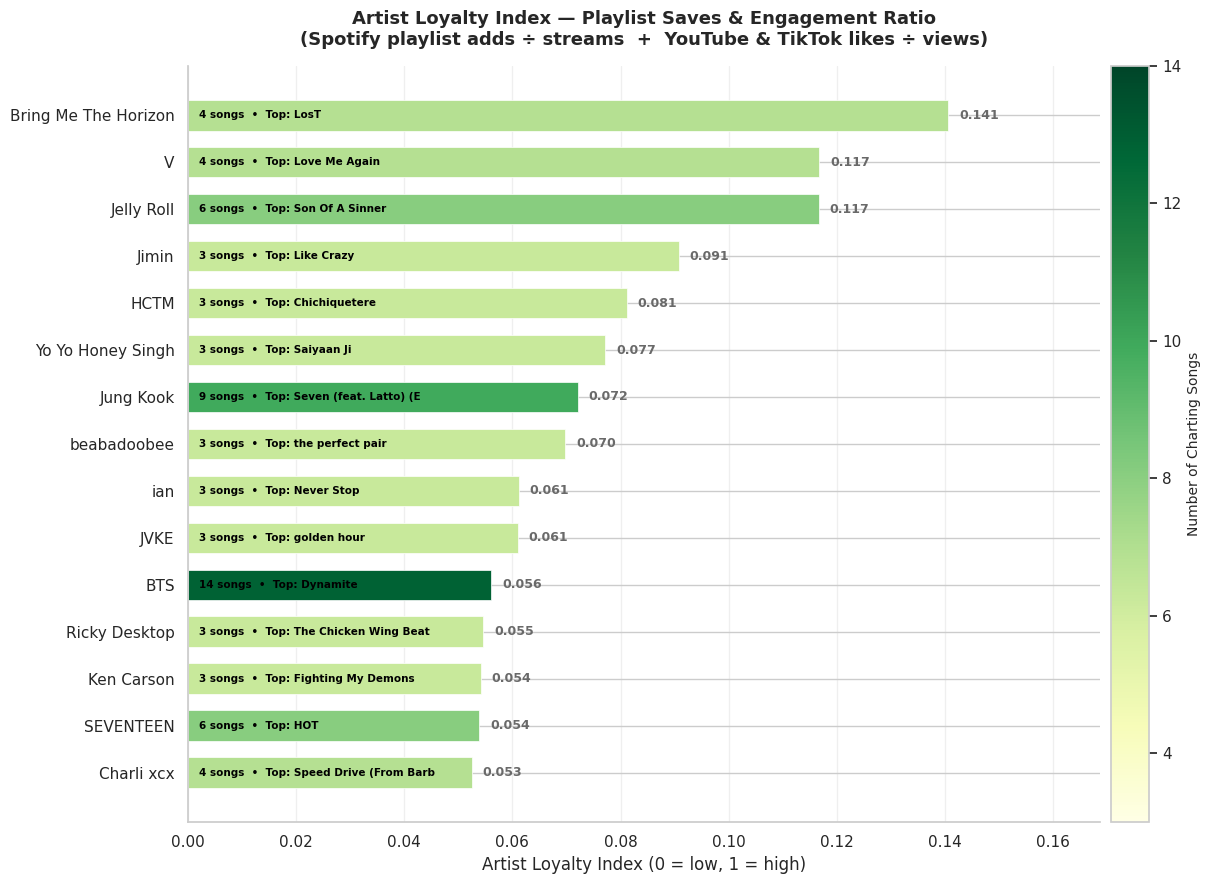

Graph saved! Analysed 377 artists with 3+ charting songs.


In [ ]:
# ================================================
# GRAPH: Artist Loyalty Index (FIXED)
# ================================================

# --- Step 1: Clean all required columns ---
loyalty_cols = [
    'Spotify Streams',
    'Spotify Playlist Count',
    'YouTube Views',
    'YouTube Likes',
    'TikTok Views',
    'TikTok Likes'
]
for col in loyalty_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''), errors='coerce'
    )

# FIX: Drop rows where Artist or Spotify Streams is NaN
df_clean = df.dropna(subset=['Artist', 'Spotify Streams']).copy()

# --- Step 2: Build loyalty score per track ---
df_clean['Spotify Loyalty'] = df_clean['Spotify Playlist Count'] / (df_clean['Spotify Streams'] + 1)
df_clean['YouTube Loyalty'] = df_clean['YouTube Likes']          / (df_clean['YouTube Views']   + 1)
df_clean['TikTok Loyalty']  = df_clean['TikTok Likes']           / (df_clean['TikTok Views']    + 1)

# Normalize each to 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

for col in ['Spotify Loyalty', 'YouTube Loyalty', 'TikTok Loyalty']:
    df_clean[col + '_norm'] = scaler.fit_transform(df_clean[[col]].fillna(0))

# Combined loyalty index
df_clean['Loyalty Index'] = (
    df_clean['Spotify Loyalty_norm'] * 0.50 +
    df_clean['YouTube Loyalty_norm'] * 0.30 +
    df_clean['TikTok Loyalty_norm']  * 0.20
)

# --- Step 3: FIX Top Track logic ---
# Find top track per artist separately to avoid NaN key issue
top_track_per_artist = (
    df_clean.sort_values('Spotify Streams', ascending=False)
    .groupby('Artist')['Track']
    .first()
    .reset_index()
    .rename(columns={'Track': 'Top_Track'})
)

# Aggregate loyalty per artist
artist_loyalty = (
    df_clean.groupby('Artist')
    .agg(
        Loyalty_Score = ('Loyalty Index', 'mean'),
        Song_Count    = ('Track',         'count'),
        Avg_Streams   = ('Spotify Streams','mean')
    )
    .reset_index()
)

# Merge top track in safely
artist_loyalty = artist_loyalty.merge(top_track_per_artist, on='Artist', how='left')

# Filter: at least 3 songs
artist_loyalty = artist_loyalty[artist_loyalty['Song_Count'] >= 3]

# --- Step 4: Top 15 most loyal fanbases ---
top_loyalty = (
    artist_loyalty
    .sort_values('Loyalty_Score', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# --- Step 5: Color by song count ---
norm_counts = (
    (top_loyalty['Song_Count'] - top_loyalty['Song_Count'].min()) /
    (top_loyalty['Song_Count'].max() - top_loyalty['Song_Count'].min() + 1)
)
bar_colors = plt.cm.YlGn(0.3 + norm_counts * 0.65)

# --- Step 6: Plot ---
fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    top_loyalty['Artist'],
    top_loyalty['Loyalty_Score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

# --- Step 7: Labels ---
for bar, (_, row) in zip(bars, top_loyalty.iterrows()):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Loyalty_Score']:.3f}",
        va='center', fontsize=9,
        color='dimgray', fontweight='bold'
    )
    top_track_label = str(row['Top_Track'])[:22] if pd.notna(row['Top_Track']) else 'N/A'
    label = f"{row['Song_Count']} songs  •  Top: {top_track_label}"
    ax.text(
        0.002,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=7.5,
        color='black', fontweight='bold'
    )

# --- Step 8: Colorbar ---
sm = plt.cm.ScalarMappable(
    cmap='YlGn',
    norm=plt.Normalize(
        vmin=top_loyalty['Song_Count'].min(),
        vmax=top_loyalty['Song_Count'].max()
    )
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Number of Charting Songs', fontsize=10)

# --- Step 9: Formatting ---
ax.invert_yaxis()
ax.set_xlabel('Artist Loyalty Index (0 = low, 1 = high)', fontsize=12)
ax.set_title(
    'Artist Loyalty Index — Playlist Saves & Engagement Ratio\n'
    '(Spotify playlist adds ÷ streams  +  YouTube & TikTok likes ÷ views)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlim(0, top_loyalty['Loyalty_Score'].max() * 1.2)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('artist_loyalty.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Graph saved! Analysed {len(artist_loyalty)} artists with 3+ charting songs.")

In [ ]:
# Get key stats for the website
df = pd.read_csv('Most Streamed Spotify Songs 2024.csv', encoding='latin-1')
df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

top_song   = df.loc[df['Spotify Streams'].idxmax(), 'Track']
top_artist = df.loc[df['Spotify Streams'].idxmax(), 'Artist']
top_streams = df['Spotify Streams'].max()
total_streams = df['Spotify Streams'].sum()
total_songs = len(df)
total_artists = df['Artist'].nunique()

print(f"Top Song:      {top_song}")
print(f"Top Artist:    {top_artist}")
print(f"Top Streams:   {top_streams:,.0f}")
print(f"Total Streams: {total_streams:,.0f}")
print(f"Total Songs:   {total_songs}")
print(f"Total Artists: {total_artists}")

Top Song:      Blinding Lights
Top Artist:    The Weeknd
Top Streams:   4,281,468,720
Total Streams: 2,007,426,881,265
Total Songs:   4600
Total Artists: 1999


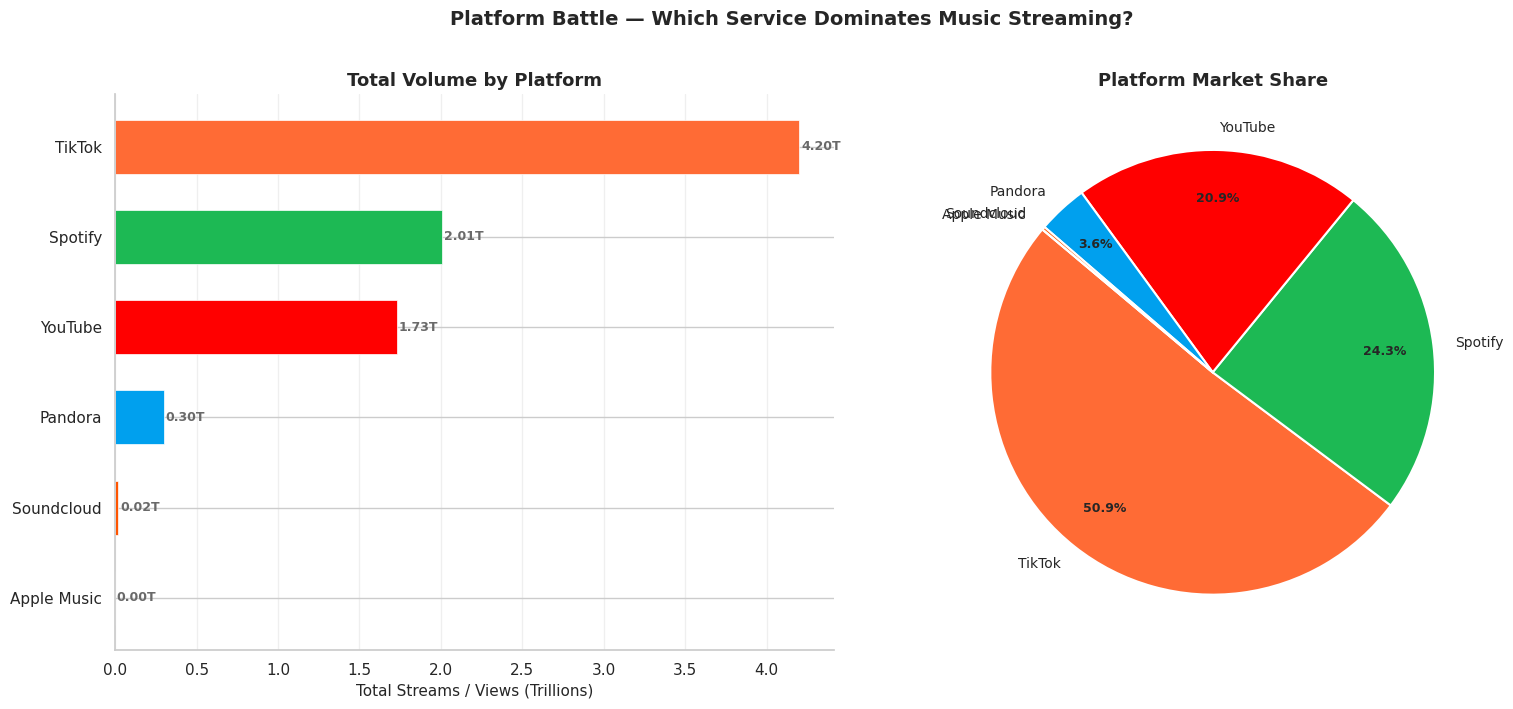

Graph A saved as platform_battle.png


In [30]:
# ================================================
# GRAPH A: Platform Battle
# Which platform dominates total streams?
# Radar chart + grouped bar chart side by side
# ================================================

# --- Step 1: Clean all platform columns ---
platform_data = {
    'Spotify':    'Spotify Streams',
    'YouTube':    'YouTube Views',
    'TikTok':     'TikTok Views',
    'Pandora':    'Pandora Streams',
    'Soundcloud': 'Soundcloud Streams',
    'Apple Music':'Apple Music Playlist Count'
}

for label, col in platform_data.items():
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''), errors='coerce'
    )

# --- Step 2: Total streams per platform ---
totals = {
    label: df[col].sum()
    for label, col in platform_data.items()
}
totals_df = pd.DataFrame(
    list(totals.items()), columns=['Platform', 'Total']
).sort_values('Total', ascending=False)

# --- Step 3: Colors per platform ---
platform_colors = {
    'Spotify':     '#1DB954',
    'YouTube':     '#FF0000',
    'TikTok':      '#FF6B35',
    'Pandora':     '#00A0EE',
    'Soundcloud':  '#FF5500',
    'Apple Music': '#FC3C44'
}
bar_colors = [platform_colors[p] for p in totals_df['Platform']]

# --- Step 4: Plot side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Horizontal bar chart
bars = ax1.barh(
    totals_df['Platform'],
    totals_df['Total'] / 1e12,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)
for bar in bars:
    ax1.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}T',
        va='center', fontsize=9,
        color='dimgray', fontweight='bold'
    )
ax1.invert_yaxis()
ax1.set_xlabel('Total Streams / Views (Trillions)', fontsize=11)
ax1.set_title('Total Volume by Platform', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RIGHT: Pie chart showing share
pie_colors = [platform_colors[p] for p in totals_df['Platform']]
wedges, texts, autotexts = ax2.pie(
    totals_df['Total'],
    labels=totals_df['Platform'],
    colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax2.set_title('Platform Market Share', fontsize=13, fontweight='bold')

plt.suptitle(
    'Platform Battle — Which Service Dominates Music Streaming?',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('platform_battle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph A saved as platform_battle.png")

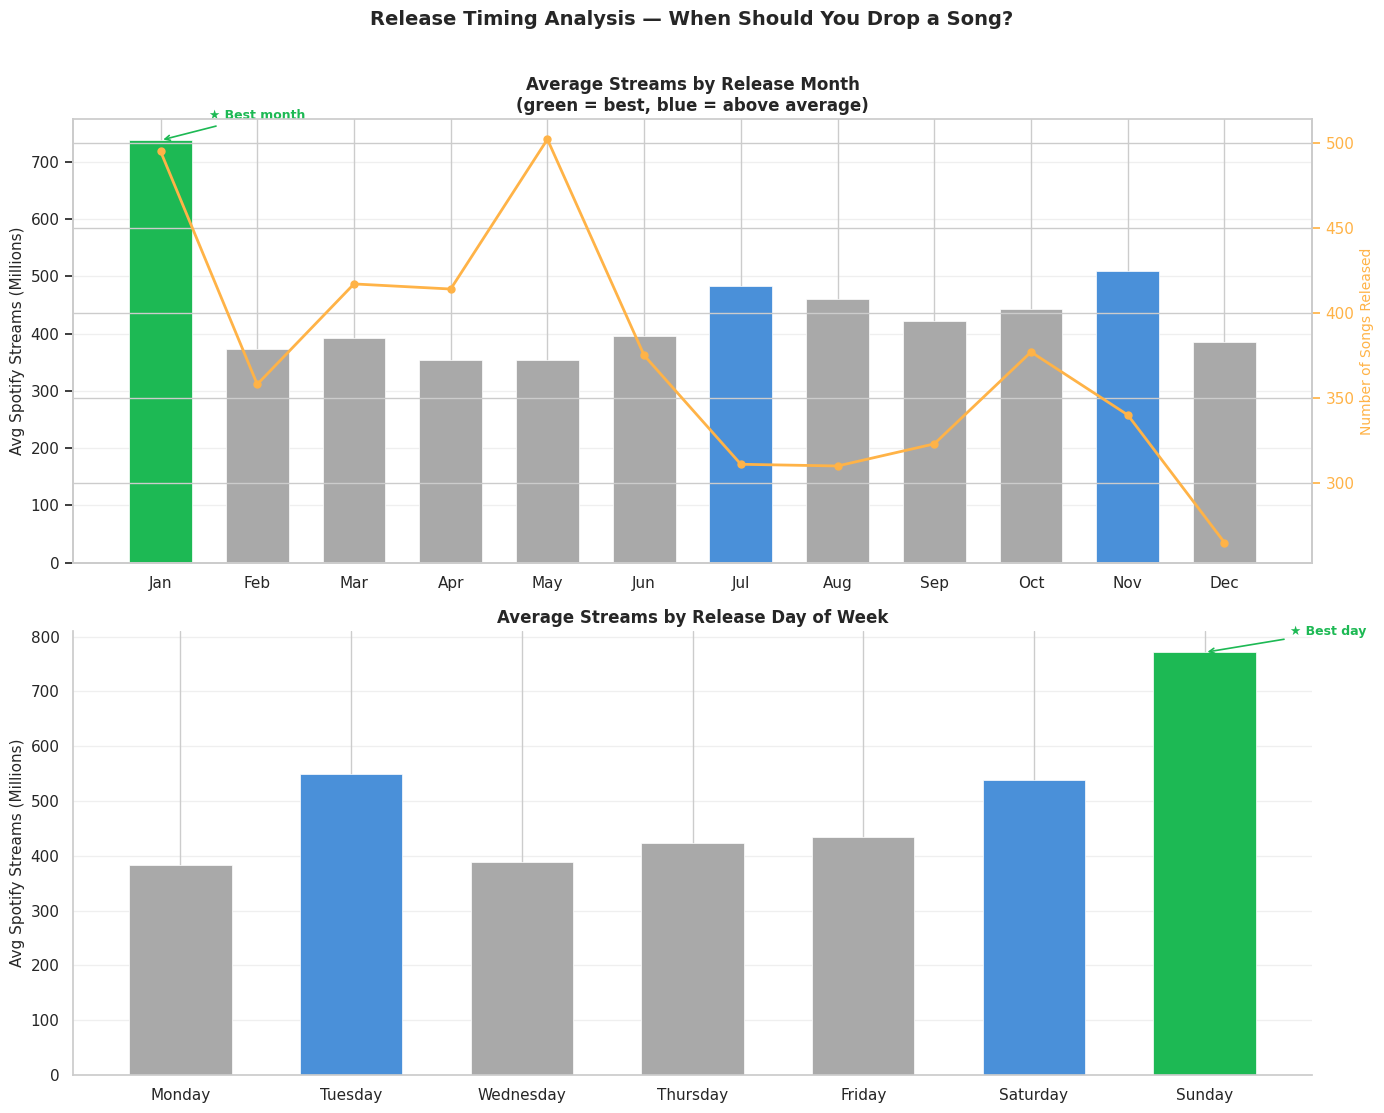

Graph D saved as release_timing.png


In [23]:
# ================================================
# GRAPH D: Release Timing Analysis
# Best month + best day to release a song
# ================================================

# --- Step 1: Parse dates ---
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Month'] = df['Release Date'].dt.month
df['Release Day']   = df['Release Date'].dt.day_name()
df['Release Year']  = df['Release Date'].dt.year

df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

timing_df = df.dropna(subset=['Release Month', 'Spotify Streams']).copy()

# --- Step 2: Avg streams by month ---
month_avg = timing_df.groupby('Release Month')['Spotify Streams'].agg(
    ['mean', 'count']
).reset_index()
month_avg.columns = ['Month', 'Avg Streams', 'Song Count']
month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_avg['Month Name'] = month_avg['Month'].apply(lambda x: month_names[x-1])

# --- Step 3: Avg streams by day of week ---
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = timing_df.groupby('Release Day')['Spotify Streams'].mean().reindex(day_order)

# --- Step 4: Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

# TOP: Monthly bar chart
month_colors = [
    '#1DB954' if v == month_avg['Avg Streams'].max()
    else '#4A90D9' if v >= month_avg['Avg Streams'].quantile(0.75)
    else '#A9A9A9'
    for v in month_avg['Avg Streams']
]
bars = ax1.bar(
    month_avg['Month Name'],
    month_avg['Avg Streams'] / 1e6,
    color=month_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.65
)
# Annotate best month
best_month_idx = month_avg['Avg Streams'].idxmax()
ax1.annotate(
    '★ Best month',
    xy=(best_month_idx, month_avg['Avg Streams'].max() / 1e6),
    xytext=(best_month_idx + 0.5, month_avg['Avg Streams'].max() / 1e6 * 1.05),
    fontsize=9, color='#1DB954', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1DB954', lw=1.2)
)
# Song count as line overlay
ax1b = ax1.twinx()
ax1b.plot(
    month_avg['Month Name'],
    month_avg['Song Count'],
    color='#FFB347', linewidth=2,
    marker='o', markersize=5, label='Songs released'
)
ax1b.set_ylabel('Number of Songs Released', fontsize=10, color='#FFB347')
ax1b.tick_params(axis='y', colors='#FFB347')

ax1.set_ylabel('Avg Spotify Streams (Millions)', fontsize=11)
ax1.set_title('Average Streams by Release Month\n(green = best, blue = above average)',
              fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)

# BOTTOM: Day of week bar chart
day_colors = [
    '#1DB954' if d == day_avg.idxmax()
    else '#4A90D9' if day_avg[d] >= day_avg.quantile(0.6)
    else '#A9A9A9'
    for d in day_order
]
ax2.bar(
    day_order,
    day_avg.values / 1e6,
    color=day_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)
best_day = day_avg.idxmax()
ax2.annotate(
    '★ Best day',
    xy=(day_order.index(best_day), day_avg.max() / 1e6),
    xytext=(day_order.index(best_day) + 0.5, day_avg.max() / 1e6 * 1.04),
    fontsize=9, color='#1DB954', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1DB954', lw=1.2)
)
ax2.set_ylabel('Avg Spotify Streams (Millions)', fontsize=11)
ax2.set_title('Average Streams by Release Day of Week',
              fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle(
    'Release Timing Analysis — When Should You Drop a Song?',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('release_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph D saved as release_timing.png")

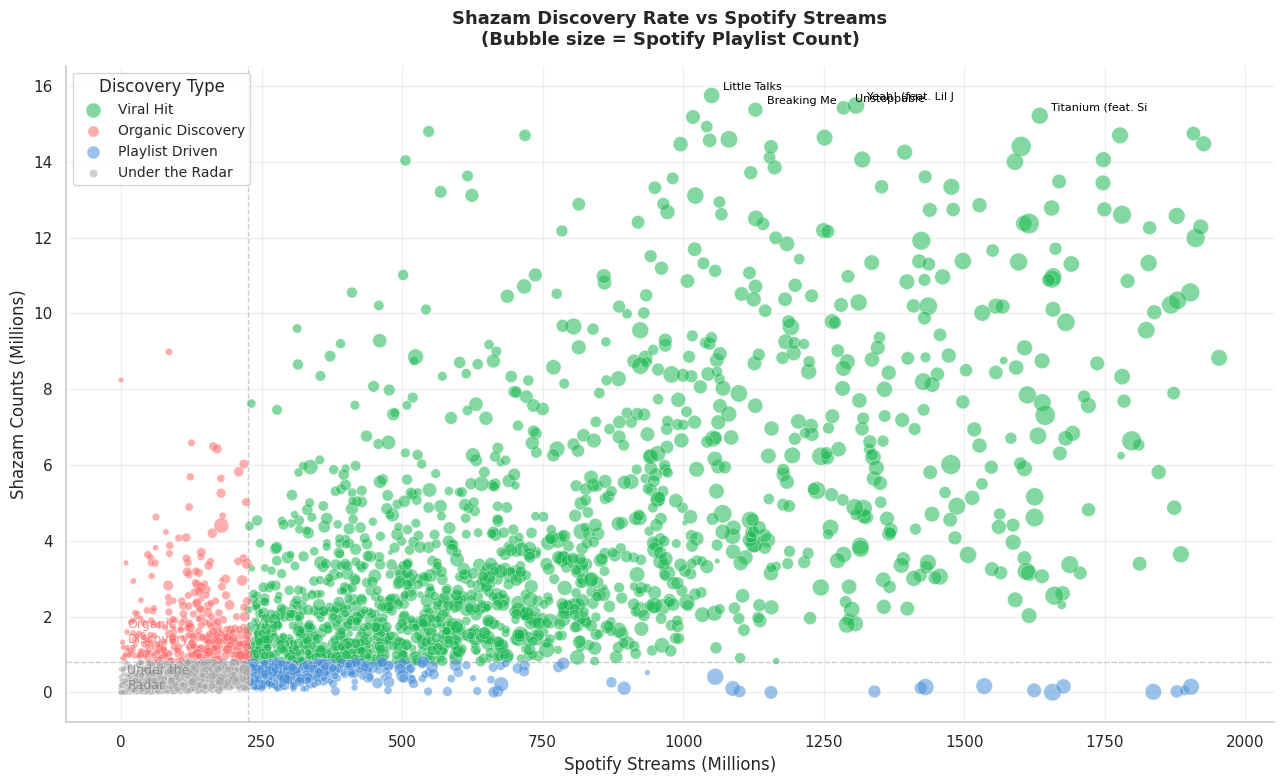

Graph E saved as shazam_discovery.png


In [24]:
# ================================================
# GRAPH E: Shazam Discovery Rate
# Shazam counts vs Spotify Streams
# High Shazam + Low Streams = organic discovery
# Low Shazam + High Streams = playlist-driven
# ================================================

# --- Step 1: Clean columns ---
for col in ['Shazam Counts', 'Spotify Streams', 'Spotify Playlist Count']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''), errors='coerce'
    )

shazam_df = df[['Track', 'Artist', 'Shazam Counts',
                'Spotify Streams', 'Spotify Playlist Count']].dropna()

# --- Step 2: Remove top 2% outliers for cleaner plot ---
s_cap  = shazam_df['Spotify Streams'].quantile(0.98)
sh_cap = shazam_df['Shazam Counts'].quantile(0.98)
shazam_df = shazam_df[
    (shazam_df['Spotify Streams'] <= s_cap) &
    (shazam_df['Shazam Counts']   <= sh_cap)
]

# --- Step 3: Discovery quadrants ---
s_med  = shazam_df['Spotify Streams'].median()
sh_med = shazam_df['Shazam Counts'].median()

def discovery_type(row):
    high_sh = row['Shazam Counts']   >= sh_med
    high_sp = row['Spotify Streams'] >= s_med
    if high_sh and not high_sp:
        return ('Organic Discovery', '#FF6B6B')
    elif high_sh and high_sp:
        return ('Viral Hit', '#1DB954')
    elif not high_sh and high_sp:
        return ('Playlist Driven', '#4A90D9')
    else:
        return ('Under the Radar', '#A9A9A9')

results = shazam_df.apply(discovery_type, axis=1)
shazam_df['Discovery Type']  = [r[0] for r in results]
shazam_df['Discovery Color'] = [r[1] for r in results]

# --- Step 4: Bubble size = playlist count ---
bubble = (
    shazam_df['Spotify Playlist Count'] /
    shazam_df['Spotify Playlist Count'].max()
) * 200 + 15

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(13, 8))

for dtype, color in [('Viral Hit',          '#1DB954'),
                      ('Organic Discovery',  '#FF6B6B'),
                      ('Playlist Driven',    '#4A90D9'),
                      ('Under the Radar',    '#A9A9A9')]:
    mask = shazam_df['Discovery Type'] == dtype
    ax.scatter(
        shazam_df[mask]['Spotify Streams'] / 1e6,
        shazam_df[mask]['Shazam Counts']   / 1e6,
        s=bubble[mask],
        c=color, alpha=0.55,
        label=dtype,
        edgecolors='white', linewidths=0.4
    )

# Annotate top 5 viral hits
top5 = shazam_df[shazam_df['Discovery Type'] == 'Viral Hit'].nlargest(5, 'Shazam Counts')
for _, row in top5.iterrows():
    ax.annotate(
        row['Track'][:18],
        xy=(row['Spotify Streams']/1e6, row['Shazam Counts']/1e6),
        xytext=(8, 4), textcoords='offset points',
        fontsize=8, color='black'
    )

# Quadrant dividers
ax.axvline(x=s_med/1e6,  color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=sh_med/1e6, color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Quadrant labels
ax.text(s_med/1e6 * 0.05, sh_med/1e6 * 1.6,
        'Organic\nDiscovery', fontsize=9, color='#FF6B6B', alpha=0.8)
ax.text(s_med/1e6 * 1.05, sh_med/1e6 * 1.6,
        'Viral\nHit', fontsize=9, color='#1DB954', alpha=0.8)
ax.text(s_med/1e6 * 1.05, sh_med/1e6 * 0.1,
        'Playlist\nDriven', fontsize=9, color='#4A90D9', alpha=0.8)
ax.text(s_med/1e6 * 0.05, sh_med/1e6 * 0.1,
        'Under the\nRadar', fontsize=9, color='gray', alpha=0.8)

ax.set_xlabel('Spotify Streams (Millions)', fontsize=12)
ax.set_ylabel('Shazam Counts (Millions)', fontsize=12)
ax.set_title(
    'Shazam Discovery Rate vs Spotify Streams\n'
    '(Bubble size = Spotify Playlist Count)',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(title='Discovery Type', fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shazam_discovery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph E saved as shazam_discovery.png")

Creating animation... this takes about 30 seconds...
Graph F saved as top10_race.gif


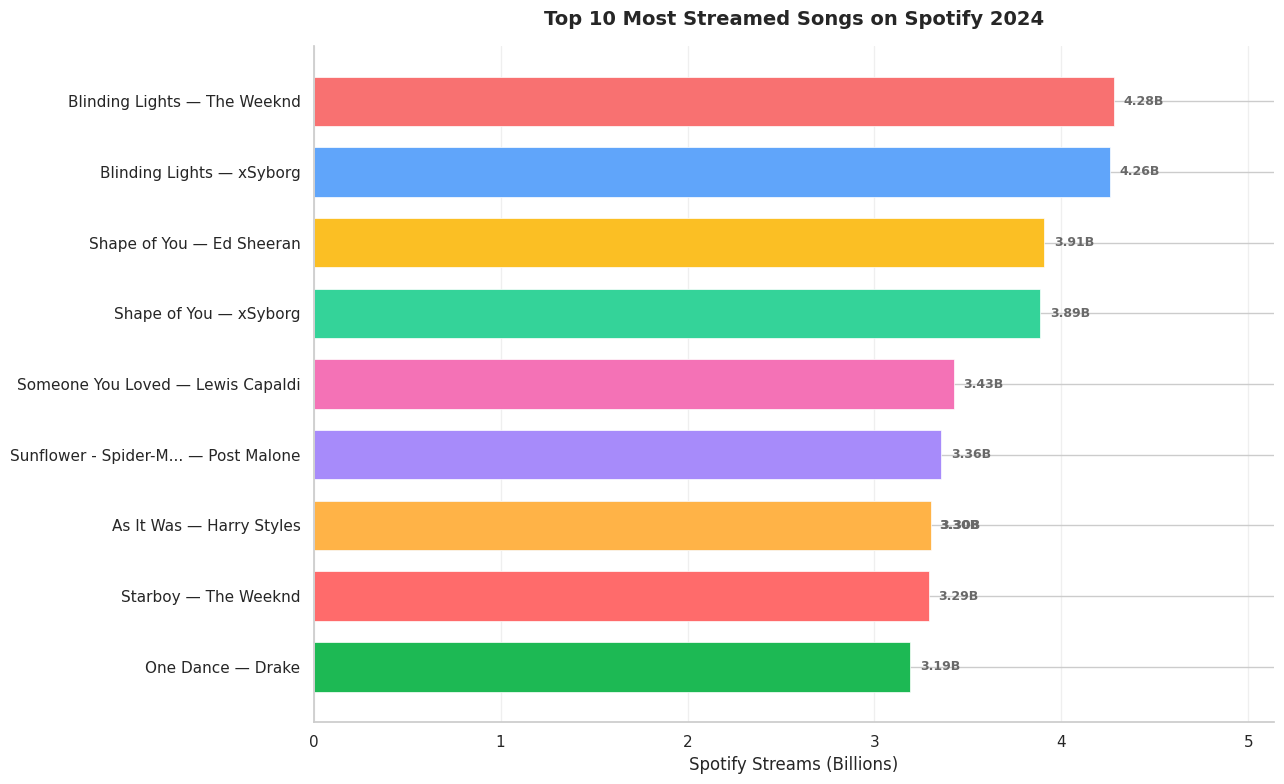

Static version saved as top10_songs.png


In [29]:
# ================================================
# GRAPH F: Top 10 Most Streamed Songs
# Animated horizontal bar chart race
# ================================================

# Note: We'll create this as an animated GIF
# Install required library first
!pip install matplotlib -q

# --- Step 1: Get top 10 songs ---
df['Spotify Streams'] = pd.to_numeric(
    df['Spotify Streams'].astype(str).str.replace(',', ''), errors='coerce'
)

top10 = (
    df[['Track', 'Artist', 'Spotify Streams']]
    .dropna()
    .sort_values('Spotify Streams', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Shorten long track names
top10['Label'] = top10.apply(
    lambda r: f"{r['Track'][:20]}... — {r['Artist'][:15]}"
              if len(r['Track']) > 20
              else f"{r['Track']} — {r['Artist'][:15]}",
    axis=1
)

# --- Step 2: Assign colors ---
colors = [
    '#1DB954','#FF6B6B','#4A90D9','#FFB347','#A78BFA',
    '#F472B6','#34D399','#FBBF24','#60A5FA','#F87171'
]

# --- Step 3: Build animation frames ---
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(13, 8))

def animate(frame):
    ax.clear()
    # Reveal bars progressively — each frame shows more of the stream count
    progress = (frame + 1) / 60   # 60 frames total
    current_streams = top10['Spotify Streams'] * progress

    # Sort by current value for race effect
    frame_df = top10.copy()
    frame_df['Current'] = current_streams
    frame_df = frame_df.sort_values('Current', ascending=True)

    bars = ax.barh(
        frame_df['Label'],
        frame_df['Current'] / 1e9,
        color=[colors[i % len(colors)] for i in range(len(frame_df))],
        edgecolor='white',
        linewidth=0.5,
        height=0.7
    )
    # Value labels
    for bar in bars:
        if bar.get_width() > 0.1:
            ax.text(
                bar.get_width() + 0.05,
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.2f}B',
                va='center', fontsize=9,
                color='dimgray', fontweight='bold'
            )

    ax.set_xlim(0, top10['Spotify Streams'].max() / 1e9 * 1.2)
    ax.set_xlabel('Spotify Streams (Billions)', fontsize=12)
    ax.set_title(
        'Top 10 Most Streamed Songs on Spotify 2024',
        fontsize=14, fontweight='bold', pad=15
    )
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

# --- Step 4: Save animation as GIF ---
print("Creating animation... this takes about 30 seconds...")
anim = FuncAnimation(fig, animate, frames=60, interval=50)
anim.save('top10_race.gif', writer='pillow', fps=20, dpi=100)
plt.close()
print("Graph F saved as top10_race.gif")

# --- Step 5: Also save static final version as PNG ---
fig2, ax2 = plt.subplots(figsize=(13, 8))
top10_sorted = top10.sort_values('Spotify Streams', ascending=True)
bars = ax2.barh(
    top10_sorted['Label'],
    top10_sorted['Spotify Streams'] / 1e9,
    color=colors[:len(top10_sorted)],
    edgecolor='white', linewidth=0.5, height=0.7
)
for bar in bars:
    ax2.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}B',
        va='center', fontsize=9,
        color='dimgray', fontweight='bold'
    )
ax2.set_xlim(0, top10['Spotify Streams'].max() / 1e9 * 1.2)
ax2.set_xlabel('Spotify Streams (Billions)', fontsize=12)
ax2.set_title('Top 10 Most Streamed Songs on Spotify 2024',
              fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('top10_songs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Static version saved as top10_songs.png")

In [27]:
from google.colab import files

graph_files = [
    'top10_songs.png',
    'platform_battle.png',
    'genre_evolution_timeline.png',
    'biggest_collabs_2024.png',
    'top_albums.png',
    'mood_vs_time_heatmap.png',
    'language_distribution.png',
    'artist_loyalty.png',
    'release_timing.png',
    'shazam_discovery.png'
]

for f in graph_files:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: top10_songs.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: release_timing.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shazam_discovery.png


In [28]:
from google.colab import files
import os

graph_files = [
    'top10_songs.png',
    'platform_battle.png',
    'genre_evolution_timeline.png',
    'biggest_collabs_2024.png',
    'top_albums.png',
    'language_distribution.png',
    'artist_loyalty.png',
    'release_timing.png',
    'shazam_discovery.png'
]

print("=== Checking files ===")
for f in graph_files:
    if os.path.exists(f):
        print(f"✓ Found — downloading: {f}")
        files.download(f)
    else:
        print(f"✗ Missing — need to re-run graph cell: {f}")

=== Checking files ===
✓ Found — downloading: top10_songs.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Found — downloading: platform_battle.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Found — downloading: shazam_discovery.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>